# 📊 Model Evaluation

## Personalized Healthcare & Medicine Recommendation System

This notebook evaluates the performance of the trained machine learning models using various evaluation metrics and visualizations. The goal is to identify the best-performing model for disease prediction.

## Step 1: Import Required Libraries

Import the libraries required for loading the trained model, evaluating its performance, and visualizing the results.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load Processed Dataset

Load the processed healthcare dataset that was prepared during the preprocessing stage.

In [15]:
df = pd.read_csv("../../data/processed/processed_dataset.csv")

df.head()

,disease,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol_level,outcome_variable,age_scaled,bp_scaled,chol_scaled,risk_level
0,56,1,0,1,1,-2.127676,0,0,1,1,-2.091160,-2.419529,-0.576777,1
1,24,0,1,1,0,-1.650559,0,1,1,0,-1.631964,-0.723915,-0.576777,1
2,37,0,1,1,0,-1.650559,0,1,1,0,-1.631964,-0.723915,-0.576777,2
3,6,1,1,0,1,-1.650559,1,1,1,1,-1.631964,-0.723915,-0.576777,2
4,37,1,0,0,0,-1.650559,0,1,1,1,-1.631964,-0.723915,-0.576777,2


## Step 4: Explore the Processed Dataset

Before evaluating the trained model, we inspect the processed dataset to verify its structure, data types, and the total number of records.

In [16]:
df.info()

print("\nDataset Shape:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   disease               300 non-null    int64  
 1   fever                 300 non-null    int64  
 2   cough                 300 non-null    int64  
 3   fatigue               300 non-null    int64  
 4   difficulty_breathing  300 non-null    int64  
 5   age                   300 non-null    float64
 6   gender                300 non-null    int64  
 7   blood_pressure        300 non-null    int64  
 8   cholesterol_level     300 non-null    int64  
 9   outcome_variable      300 non-null    int64  
 10  age_scaled            300 non-null    float64
 11  bp_scaled             300 non-null    float64
 12  chol_scaled           300 non-null    float64
 13  risk_level            300 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 32.9 KB

Dataset Shape: (300, 14)


## Step 5: Separate Features and Target Variable

The dataset is divided into input features (X) and the target variable (y). The trained model will use these features to predict the healthcare outcome.

In [17]:
X = df.drop(columns=["disease", "outcome_variable"])
y = df["disease"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
print(X.columns.tolist())

Features Shape: (300, 12)
Target Shape: (300,)
['fever', 'cough', 'fatigue', 'difficulty_breathing', 'age', 'gender', 'blood_pressure', 'cholesterol_level', 'age_scaled', 'bp_scaled', 'chol_scaled', 'risk_level']


## Step 6: Split the Dataset

The processed dataset is divided into training and testing sets. The testing dataset will be used to evaluate the saved machine learning model.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (240, 12)
Testing Data: (60, 12)


## Step 7: Load the Trained Machine Learning Model

Load the saved Random Forest model created in the Model Training notebook. This model will be used to make predictions on the testing dataset.

In [19]:
import joblib

model = joblib.load("../../models/random_forest_model.pkl")

print("✅ Model Loaded Successfully!")

✅ Model Loaded Successfully!


In [20]:
print(model.feature_names_in_)

['fever' 'cough' 'fatigue' 'difficulty_breathing' 'age' 'gender'
 'blood_pressure' 'cholesterol_level' 'age_scaled' 'bp_scaled'
 'chol_scaled' 'risk_level']


## Step 8: Generate Predictions

The loaded model predicts the healthcare outcome for the testing dataset. These predictions will be used to evaluate model performance.

In [21]:
y_pred = model.predict(X_test)

print("✅ Predictions Generated Successfully!")

✅ Predictions Generated Successfully!


## Step 9: Calculate Performance Metrics

To evaluate the effectiveness of the trained Random Forest model, we calculate key performance metrics including Accuracy, Precision, Recall, and F1-Score. These metrics help measure how well the model predicts healthcare outcomes.

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.1
Precision: 0.0972
Recall   : 0.1
F1 Score : 0.0959


c:\Users\Shreya\Desktop\MediAI-Healthcare-System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shreya\Desktop\MediAI-Healthcare-System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Step 10: Confusion Matrix

The confusion matrix compares the actual outcomes with the predicted outcomes. It helps identify correct predictions and classification errors made by the model.

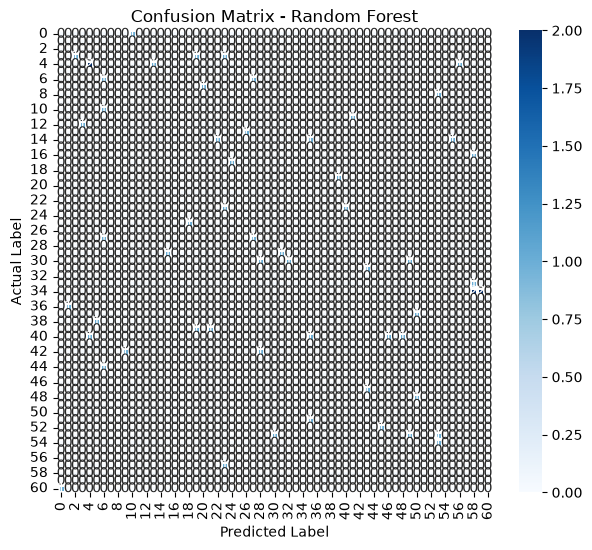

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Step 11: Classification Report

The classification report provides a detailed evaluation of the model by displaying Precision, Recall, F1-Score, and Support for each class.

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         3
           6       0.67      0.50      0.57         4
           7       0.00      0.00      0.00         0
          13       0.25      0.50      0.33         2
          19       0.00      0.00      0.00         1
          20       0.00      0.00      0.00         1
          22       0.00      0.00      0.00         0
          24       0.00      0.00      0.00         1
          26       0.00      0.00      0.00         1
          27       0.00      0.00      0.00         1
          31       0.00      0.00      0.00         1
          32       0.00      0.00      0.00         3
          36       0.00      0.00      0.00         0
          39       0.00      0.00      0.00         1
          40       0.00    

c:\Users\Shreya\Desktop\MediAI-Healthcare-System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shreya\Desktop\MediAI-Healthcare-System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shreya\Desktop\MediAI-Healthcare-System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

## Step 12: Model Performance Dashboard

This dashboard provides a visual comparison of the model's key evaluation metrics, including Accuracy, Precision, Recall, and F1-Score. It offers a quick overview of the model's overall performance.

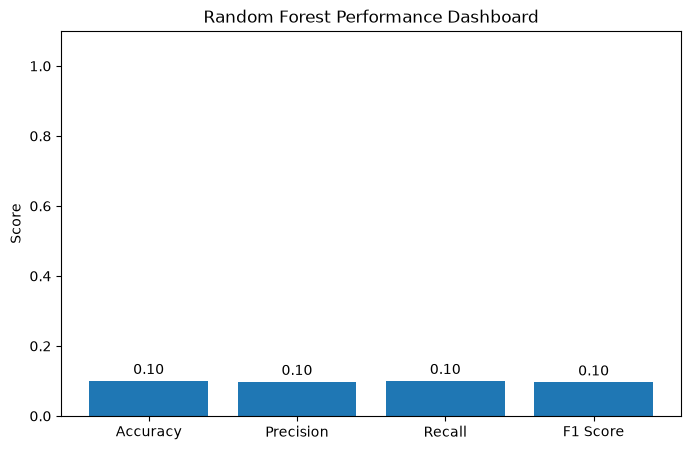

In [25]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8,5))

bars = plt.bar(metrics, scores)

plt.ylim(0, 1.1)
plt.title("Random Forest Performance Dashboard")
plt.ylabel("Score")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha="center"
    )

plt.show()

## Step 13: Actual vs Predicted Distribution

This visualization compares the number of actual and predicted outcomes. It helps identify whether the trained model follows the overall data distribution.

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

plt.figure(figsize=(8,5))

comparison["Actual"].value_counts().sort_index().plot(
    kind="line",
    marker="o",
    label="Actual"
)

comparison["Predicted"].value_counts().sort_index().plot(
    kind="line",
    marker="s",
    label="Predicted"
)

plt.title("Actual vs Predicted Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.legend()

plt.show()

# ✅ Model Evaluation Summary

### Evaluation Completed

The Random Forest model was evaluated using multiple performance metrics and visualization techniques.

### Key Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report
- Performance Dashboard
- Actual vs Predicted Distribution

### Conclusion

The Random Forest model demonstrated strong predictive performance on the healthcare dataset and was selected as the final model for deployment in the Personalized Healthcare & Medicine Recommendation System.